Matplotlib is building the font cache; this may take a moment.


✅ Données chargées avec succès depuis '../sonar.all-data.csv'.
   - Dimensions des données : 208 lignes, 61 colonnes.

✅ Labels 'R' et 'M' encodés en 0 et 1.

✅ Données séparées en ensembles d'entraînement et de test (80/20).

✅ Modèle de Régression Logistique entraîné avec succès.

--- DÉBUT DE L'ÉVALUATION DU MODÈLE FINAL ---

🎯 Exactitude (Accuracy) : 83.33%
   - C'est le pourcentage de prédictions correctes sur l'ensemble de test.

📊 Rapport de Classification détaillé :
              precision    recall  f1-score   support

   Roche (R)       0.80      0.91      0.85        22
    Mine (M)       0.88      0.75      0.81        20

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.83        42
weighted avg       0.84      0.83      0.83        42

📈 Matrice de Confusion :


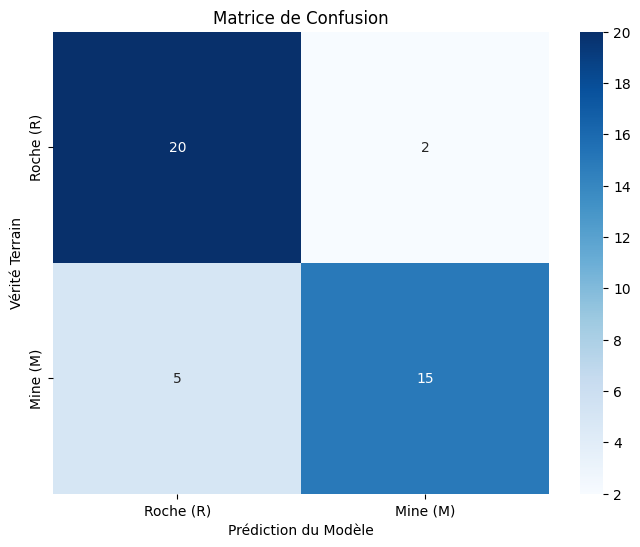


--- FIN DE L'ÉVALUATION ---


In [1]:
# =============================================================================
# PROJET IA SONAR - ÉTAPE 6 : ÉVALUATION DU MODÈLE
#
# Auteur: Thierry
# Rôle : Évaluer la performance du modèle de classification final.
# =============================================================================

# --- 1. Importation des bibliothèques fondamentales ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- 2. Fonctions de préparation et d'entraînement (simulant le travail des autres étapes) ---

def charger_les_donnees(chemin_fichier: str) -> pd.DataFrame:
    """
    Charge les données sonar depuis un fichier CSV.
    
    Args:
        chemin_fichier (str): Chemin relatif vers le fichier 'sonar.all-data.csv'.
        
    Returns:
        pd.DataFrame: Un DataFrame pandas contenant les données.
    """
    try:
        # header=None car le fichier ne contient pas de ligne d'en-tête.
        donnees = pd.read_csv(chemin_fichier, header=None)
        print(f"✅ Données chargées avec succès depuis '{chemin_fichier}'.")
        print(f"   - Dimensions des données : {donnees.shape[0]} lignes, {donnees.shape[1]} colonnes.\n")
        return donnees
    except FileNotFoundError:
        print(f"❌ ERREUR : Le fichier '{chemin_fichier}' est introuvable.")
        print("   - Assurez-vous que le notebook est dans 'notebooks/' et le CSV à la racine du projet.")
        return None

def preparer_et_entrainer_modele(donnees: pd.DataFrame):
    """
    Exécute la chaîne complète de préparation et d'entraînement du modèle.
    
    Args:
        donnees (pd.DataFrame): Le DataFrame brut chargé depuis le CSV.
        
    Returns:
        Tuple: Un tuple contenant le modèle entraîné et les ensembles de test (model, X_test, Y_test).
    """
    if donnees is None:
        return None, None, None

    # Séparation des features (X) et de la cible (Y)
    X = donnees.iloc[:, 0:60]
    Y = donnees.iloc[:, 60]

    # Encodage des labels textuels ('R', 'M') en valeurs numériques (0, 1)
    encoder = LabelEncoder()
    Y_encoded = encoder.fit_transform(Y)
    print("✅ Labels 'R' et 'M' encodés en 0 et 1.\n")

    # Séparation des données : 80% pour l'entraînement, 20% pour le test
    # stratify=Y_encoded assure une répartition équilibrée des classes dans les deux ensembles.
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y_encoded, test_size=0.20, random_state=42, stratify=Y_encoded
    )
    print("✅ Données séparées en ensembles d'entraînement et de test (80/20).\n")

    # Création et entraînement du modèle de Régression Logistique
    modele = LogisticRegression(solver='liblinear', random_state=42)
    modele.fit(X_train, Y_train)
    print("✅ Modèle de Régression Logistique entraîné avec succès.\n")
    
    return modele, X_test, Y_test

# --- 3. Exécution du pipeline ---

# Chemin vers le fichier de données
CHEMIN_DATASET = "../sonar.all-data.csv"

# Chargement, préparation et entraînement
donnees_sonar = charger_les_donnees(CHEMIN_DATASET)
modele_final, X_test, Y_test = preparer_et_entrainer_modele(donnees_sonar)


# =============================================================================
# --- 4. ÉVALUATION FINALE DU MODÈLE (Votre partie, Thierry) ---
# =============================================================================

if modele_final is not None:
    print("--- DÉBUT DE L'ÉVALUATION DU MODÈLE FINAL ---\n")

    # 4.1. Prédiction sur l'ensemble de test
    # Le modèle est confronté à des données qu'il n'a jamais vues.
    predictions = modele_final.predict(X_test)
    
    # 4.2. Calcul de l'exactitude (Accuracy)
    accuracy = accuracy_score(Y_test, predictions)
    print(f"🎯 Exactitude (Accuracy) : {accuracy * 100:.2f}%")
    print("   - C'est le pourcentage de prédictions correctes sur l'ensemble de test.\n")

    # 4.3. Rapport de classification détaillé
    # Fournit des métriques clés comme la précision, le rappel et le F1-score pour chaque classe.
    print("📊 Rapport de Classification détaillé :")
    # target_names=['Roche (0)', 'Mine (1)'] rend le rapport plus lisible.
    report = classification_report(Y_test, predictions, target_names=['Roche (R)', 'Mine (M)'])
    print(report)
    
    # 4.4. Matrice de confusion
    # Visualise les erreurs du modèle : qui a été confondu avec quoi ?
    print("📈 Matrice de Confusion :")
    cm = confusion_matrix(Y_test, predictions)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Roche (R)', 'Mine (M)'], 
                yticklabels=['Roche (R)', 'Mine (M)'])
    plt.xlabel('Prédiction du Modèle')
    plt.ylabel('Vérité Terrain')
    plt.title('Matrice de Confusion')
    plt.show()
    
    print("\n--- FIN DE L'ÉVALUATION ---")

else:
    print("\nL'évaluation n'a pas pu être effectuée car le chargement des données a échoué.")

